# Introducción

# Preparación de los datos

Comenzaremos importando nuestras librerías y cargando nuestros datasets

In [55]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats as st

In [56]:
calls = pd.read_csv("datasets/telecom_dataset_new.csv")
clients = pd.read_csv("datasets/telecom_clients.csv")

# Exploración de los datos

## calls

In [57]:
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB


In [58]:
calls.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


In [59]:
calls.tail()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
53897,168606,2019-11-10 00:00:00+03:00,out,True,957922.0,True,1,0,38
53898,168606,2019-11-11 00:00:00+03:00,out,True,957922.0,False,2,479,501
53899,168606,2019-11-15 00:00:00+03:00,out,True,957922.0,False,4,3130,3190
53900,168606,2019-11-15 00:00:00+03:00,out,True,957922.0,False,4,3130,3190
53901,168606,2019-11-19 00:00:00+03:00,in,False,NaN,True,2,0,64


`.head()` y `.tail()` nos muestran que las filas con valores nulos de la columna `operator_id` fueron llamadas entrantes (`in`) verifiquemos cuantos valores nulos tienen las llamadas entrantes y las llamadas salientes

In [60]:
calls_in = calls[calls["direction"] == "in"]

calls_in.isna().sum()

user_id                   0
date                      0
direction                 0
internal                115
operator_id            7972
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

In [61]:
calls_out = calls[calls["direction"] == "out"]

calls_out.isna().sum()

user_id                  0
date                     0
direction                0
internal                 2
operator_id            200
is_missed_call           0
calls_count              0
call_duration            0
total_call_duration      0
dtype: int64

In [62]:
calls.duplicated().sum()

np.int64(4900)

In [63]:
calls_dup = calls[calls.duplicated() == True]


El DataFrame `calls` contiene nueve columnas y 53902 filas. 

Las columnas `internal` y `operator_id` contienen valores nulos que se trataran de forma diferente. Un valor nulo en `operator_id` para llamadas entrantes puede representar una llamada perdida, mientras que un valor nulo en llamadas salientes puede implicar un error con el registro de los datos, por lo que se conservaran los valores nulos de llamadas entrantes y se eliminaran los valores nulos de llamadas salientes. 

En el caso de los valores nulos de la columna `internal` se eliminaran todos, ya que no tenemos forma de saber si fue una llamada interna o externa. 

Eliminar estos valores nulos no provocara perdida significativa de la información en el análisis de datos ya que no representan una porción significativa de los datos

Se encontraron 4900 duplicados explícitos que podrían ser un error con la captura de los datos, por lo que se eliminaran completamente

También, es necesario cambiar el tipo de datos de la columna `date` a datetime 

# clients

In [64]:
clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB


In [65]:
clients.head()

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


In [66]:
clients.tail()

,user_id,tariff_plan,date_start
727,166554,B,2019-08-08
728,166911,B,2019-08-23
729,167012,B,2019-08-28
730,166867,B,2019-08-22
731,166565,B,2019-08-08


In [67]:
clients.duplicated().sum()

np.int64(0)

El DataFrame `clients` contiene 3 columnas y 732 filas.

No se encontraron valores nulos ni duplicados, unicamente hace falta cambiar el tipo de datos de la columna `date_start` a datetime

# Procesamiento de datos

# calls

Eliminamos valores duplicados y nulos y cambiamos el tipo de datos de la columna `date`

In [68]:
# Eliminamos duplicados
calls = calls.drop_duplicates()

# Eliminamos llamadas salientes sin operator_id
calls = calls[~((calls["direction"] == "out") & (calls["operator_id"].isna()))]

# Eliminamos filas con internal nulo
calls = calls[calls["internal"].notna()]

calls.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48708 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              48708 non-null  int64  
 1   date                 48708 non-null  object 
 2   direction            48708 non-null  object 
 3   internal             48708 non-null  object 
 4   operator_id          41491 non-null  float64
 5   is_missed_call       48708 non-null  bool   
 6   calls_count          48708 non-null  int64  
 7   call_duration        48708 non-null  int64  
 8   total_call_duration  48708 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.4+ MB


Después de realizar la limpieza nos queda un DataFrame con 48708 filas y 7217 nulos que representan llamadas perdidas

A continuación, convertimos la columna `date`

In [69]:
calls["date"] = pd.to_datetime(calls["date"], utc=True).dt.normalize().dt.tz_localize(None)

print(calls["date"].dtype)

datetime64[ns]


Se cambia a datetime y se deja unicamente la fecha ya que la información respecto a la hora no aportaba nada

# clients

Para `clients` unicamente convertimos el tipo de datos de la columna `date_start`

In [70]:
clients["date_start"] = pd.to_datetime(clients["date_start"])

print(clients["date_start"].dtype)

datetime64[ns]


# Análisis exploratorio

Comenzamos aplicando el método `.describe()` sobre nuestro DataFrame `calls`

In [71]:
calls.describe()

,user_id,date,operator_id,calls_count,call_duration,total_call_duration
count,48708.000000,48708,41491.000000,48708.000000,48708.000000,48708.000000
mean,167293.417775,2019-10-22 00:59:44.922394880,916516.771155,16.546953,867.758027,1159.638540
min,166377.000000,2019-08-01 00:00:00,879896.000000,1.000000,0.000000,0.000000
25%,166782.000000,2019-10-03 00:00:00,900790.000000,1.000000,0.000000,47.000000
50%,167158.000000,2019-10-27 00:00:00,913938.000000,4.000000,38.000000,211.000000
75%,167816.000000,2019-11-13 00:00:00,937708.000000,12.000000,574.000000,904.000000
max,168606.000000,2019-11-27 00:00:00,973286.000000,4817.000000,144395.000000,166155.000000
std,598.202174,NaN,21234.081589,63.785515,3782.428763,4460.796951


La presencia de valores máximos muy por encima de la media nos indica que existen valores atípicos en nuestro DataFrame

También observamos que el valor mínimo de `call_duration` y `total_call_duration` es de 0 segundos, esto en llamadas perdidas es normal, pero en llamadas registradas como no perdidas puede significar un error con la llamada o con la captura de los datos.

Antes de trabajar con los valores atípicos, comprobemos cuantas llamadas no perdidas tienen una duración de 0

In [73]:
non_missed_calls = calls[(calls["call_duration"] == 0) & (calls["is_missed_call"] == False)]
percent_nmc = len(non_missed_calls) / len(calls) * 100
print(f"Llamadas atendidas con duración de 0: {len(non_missed_calls)}")
print(f"Proporción que representan de los datos: {percent_nmc:.2f}%")

Llamadas atendidas con duración de 0: 17
Proporción que representan de los datos: 0.03%


Solo existen 17 llamadas tomadas con un valor de 0, lo que representa el 0.03% de nuestros datos, en vista de que no es una proporción significativa de estos y que no aportan ningún valor al negocio procederemos con la eliminación de estos 17 registros

In [ ]:
calls = calls[~((calls["call_duration"] == 0) & (calls["is_missed_call"] == False))]

Debido al tamaño de los valores atípicos utilizaremos gráficos de dispersión para facilitar su observación. Se agrego el calculo de los percentiles 95 y 99 para ver la cantidad de datos que superan esos umbrales

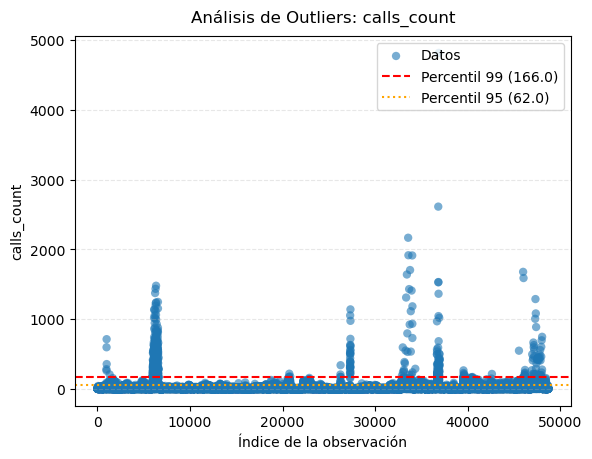

calls_count -> El 95% de los datos está abajo de: 62.00
calls_count -> El 99% de los datos está abajo de: 166.00
--------------------------------------------------


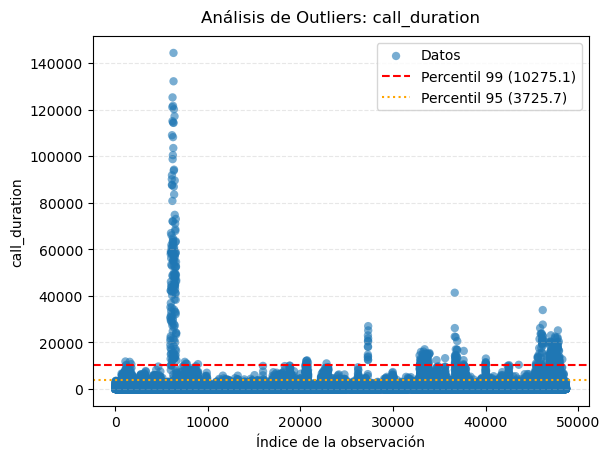

call_duration -> El 95% de los datos está abajo de: 3725.65
call_duration -> El 99% de los datos está abajo de: 10275.09
--------------------------------------------------


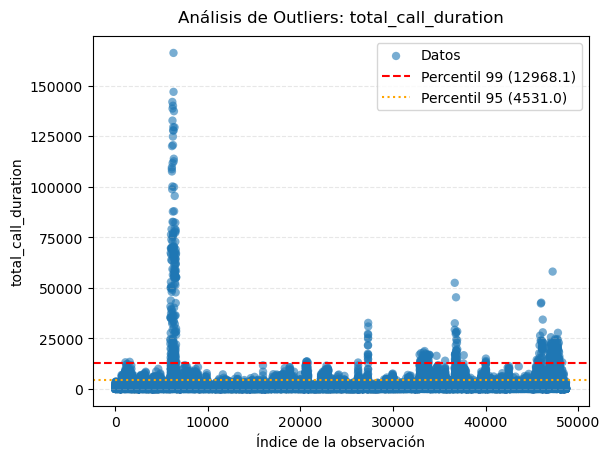

total_call_duration -> El 95% de los datos está abajo de: 4531.00
total_call_duration -> El 99% de los datos está abajo de: 12968.09
--------------------------------------------------


In [102]:
atypicals = ['calls_count', 'call_duration', 'total_call_duration']

for col in atypicals:
    plt.figure()
    
    x_values = range(0, len(calls[col]))
    plt.scatter(x_values, calls[col], alpha=0.6, edgecolor='none', label='Datos')
    
    p95 = calls[col].quantile(0.95)
    p99 = calls[col].quantile(0.99)
    
    
    plt.title(f"Análisis de Outliers: {col}", fontsize=12, pad=10)
    plt.xlabel("Índice de la observación")
    plt.ylabel(col)
    plt.axhline(y=p99, color='red', linestyle='--', linewidth=1.5, label=f'Percentil 99 ({p99:.1f})')
    plt.axhline(y=p95, color='orange', linestyle=':', linewidth=1.5, label=f'Percentil 95 ({p95:.1f})')
    plt.legend(loc='upper right')
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    
    plt.show()
    
    
    print(f"{col} -> El 95% de los datos está abajo de: {p95:.2f}")
    print(f"{col} -> El 99% de los datos está abajo de: {p99:.2f}\n" + "-"*50)

Observemos mas de cerca el 95% de nuestros datos

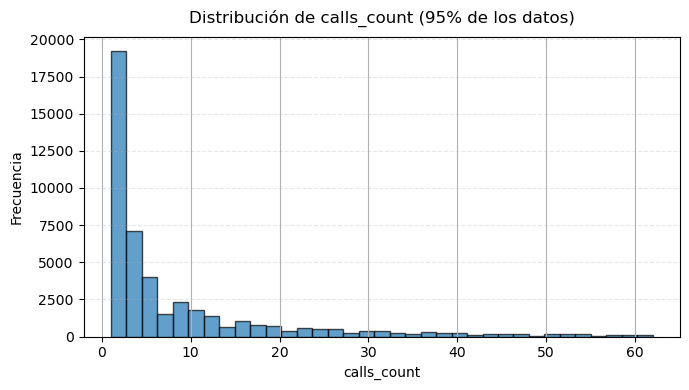

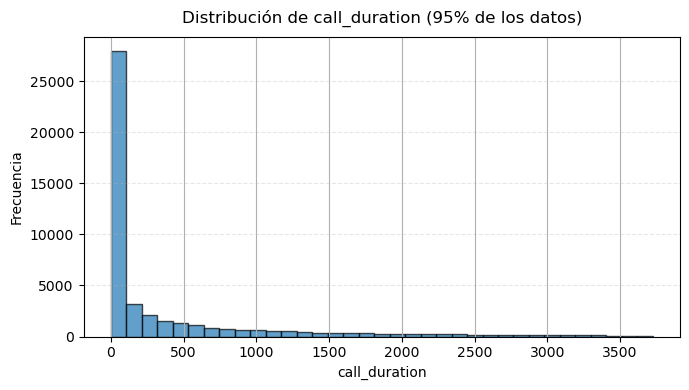

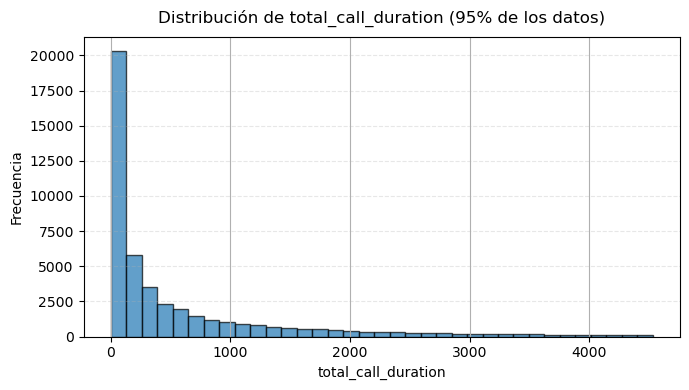

In [ ]:
atypicals = ['calls_count', 'call_duration', 'total_call_duration']

for col in atypicals:
    plt.figure(figsize=(7, 4))
    
    
    limite_95 = calls[col].quantile(0.95)
    
    
    datos_tipicos = calls[calls[col] <= limite_95][col]
    
    
    datos_tipicos.hist(bins=35, edgecolor='black', alpha=0.7)
    
    
    plt.title(f"Distribución de {col} (95% de los datos)", fontsize=12, pad=10)
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.grid(axis='y', linestyle='--', alpha=0.3) 
    
    plt.tight_layout()
    plt.show()

Las variables de conteo y duración de llamadas no siguen una distribución normal. Al contrario, están fuertemente sesgadas a la derecha. El 95% de los datos se concentra en valores bajos, pero existe una presencia masiva de valores atípicos en el extremo derecho.

En los gráficos de dispersión, se observa que los valores atípicos no son eventos aislados o dispersos, sino que forman bloques densos (especialmente visibles en las acumulaciones verticales). Esto demuestra que corresponden a un comportamiento operativo real y sistemático, no a errores aleatorios de un solo registro. En los histogramas, fue necesario aplicar un filtro visual al percentil 95 para poder apreciar la verdadera forma y comportamiento de la masa central de los datos, la cual quedaba completamente invisibilizada por la escala de los valores máximos.

Para no sesgar el análisis ni eliminar información valiosa sobre el rendimiento del negocio, no se removerá ningún dato del dataset original. Sin embargo, dado que los promedios corrientes se ven severamente inflados por estos outliers, para la evaluación de los operadores se descarta el uso de la media aritmética y se optará por métricas robustas a valores extremos, como la mediana, además de segmentar el análisis de rendimiento entre llamadas típicas y casos atípicos.